# 07 — Results Comparison
Combine all 4 experiments into one master results table and final charts.
This is the content that goes directly into the submission report.

✅ Loaded 4 metric files → 16 rows
                  Experiment             Model       MAE       RMSE      R2       MAPE
        A - No Wildfire Risk     Naive (Lag-1) 866787.71 2247699.18 -0.7193 7956853.64
        A - No Wildfire Risk             Ridge 252793.23  648090.97  0.8571 3494542.63
        A - No Wildfire Risk     Random Forest  62861.07  272481.32  0.9747      71.45
        A - No Wildfire Risk Gradient Boosting  79010.32  245963.11  0.9794  145505.94
B - Provided Fire Risk Score     Naive (Lag-1) 866787.71 2247699.18 -0.7193 7956853.64
B - Provided Fire Risk Score             Ridge 244341.10  642283.09  0.8596 2665330.86
B - Provided Fire Risk Score     Random Forest  63279.41  279253.03  0.9735      70.60
B - Provided Fire Risk Score Gradient Boosting  79590.69  249453.45  0.9788  148944.22
 C - Classical Wildfire Risk     Naive (Lag-1) 866787.71 2247699.18 -0.7193 7956853.64
 C - Classical Wildfire Risk             Ridge 252119.61  647579.44  0.8573 3416218.94
 C - Clas

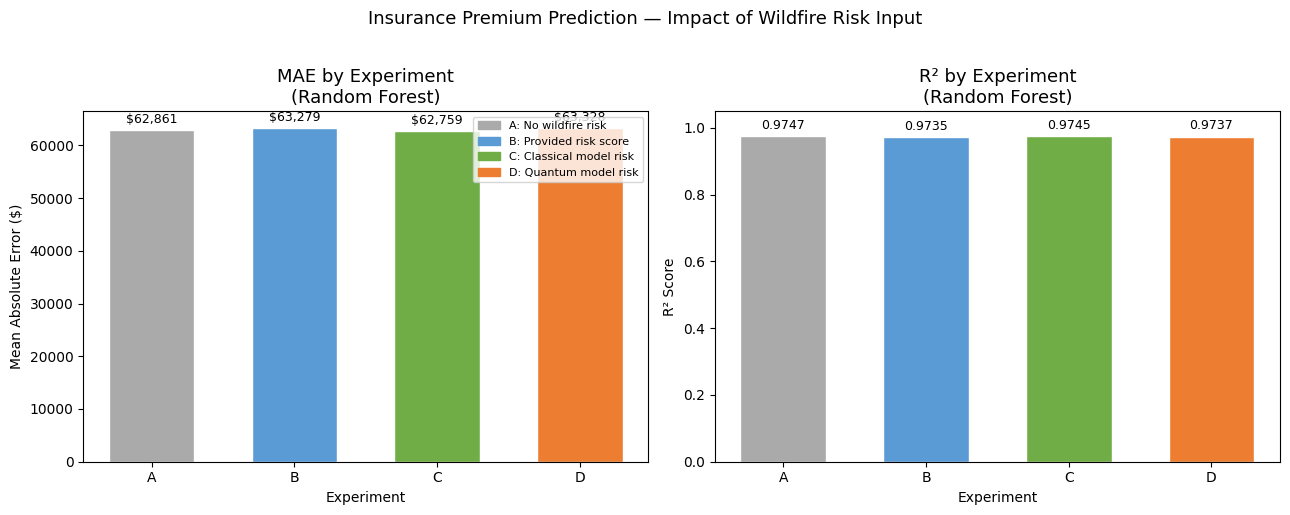

💾 Saved → results/figures/experiment_comparison.png

=== KEY FINDINGS ===
Baseline (A) — MAE: $62,861  R²: 0.9747
B - Provided Fire Risk Score   MAE: $63,279  R²: 0.9735  ⚠️  no improvement (-0.7%)
C - Classical Wildfire Risk    MAE: $62,759  R²: 0.9745  ✅ improved (+0.2%)
D - Quantum Wildfire Risk      MAE: $63,328  R²: 0.9737  ⚠️  no improvement (-0.7%)

✅ Notebook 07 complete — all results ready for report!


In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.utils import load_all_metrics
from src.config import FIGURES_DIR, METRICS_DIR

# ── 1. Load all experiment results ────────────────────────────────────────────
all_results = load_all_metrics()
print(all_results.to_string(index=False))

# ── 2. Save combined master table ─────────────────────────────────────────────
METRICS_DIR.mkdir(parents=True, exist_ok=True)
all_results.to_csv(METRICS_DIR / 'all_experiments_combined.csv', index=False)
print('\n💾 Saved → results/metrics/all_experiments_combined.csv')

# ── 3. MAE comparison chart (best model = Random Forest) ──────────────────────
rf_results = all_results[all_results['Model'] == 'Random Forest'].copy()
rf_results['Label'] = rf_results['Experiment'].str.extract(r'^([A-D])')

colors = ['#aaaaaa', '#5b9bd5', '#70ad47', '#ed7d31']
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MAE bar chart
bars1 = axes[0].bar(rf_results['Label'], rf_results['MAE'],
                    color=colors[:len(rf_results)], edgecolor='white', width=0.6)
axes[0].set_title('MAE by Experiment\n(Random Forest)', fontsize=13)
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=9)

# R2 bar chart
bars2 = axes[1].bar(rf_results['Label'], rf_results['R2'],
                    color=colors[:len(rf_results)], edgecolor='white', width=0.6)
axes[1].set_title('R² by Experiment\n(Random Forest)', fontsize=13)
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
axes[1].bar_label(bars2, fmt='{:.4f}', padding=3, fontsize=9)

legend_labels = [
    'A: No wildfire risk',
    'B: Provided risk score',
    'C: Classical model risk',
    'D: Quantum model risk',
]
patches = [mpatches.Patch(color=colors[i], label=legend_labels[i])
           for i in range(len(rf_results))]
axes[0].legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle('Insurance Premium Prediction — Impact of Wildfire Risk Input',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → results/figures/experiment_comparison.png')

# ── 4. Key findings ───────────────────────────────────────────────────────────
print('\n=== KEY FINDINGS ===')
rf = all_results[all_results['Model'] == 'Random Forest'].set_index('Experiment')

exp_order = [e for e in rf.index if e.startswith('A')]
if exp_order:
    base_mae = rf.loc[exp_order[0], 'MAE']
    base_r2  = rf.loc[exp_order[0], 'R2']
    print(f'Baseline (A) — MAE: ${base_mae:,.0f}  R²: {base_r2:.4f}')

for exp in rf.index:
    if not exp.startswith('A'):
        mae = rf.loc[exp, 'MAE']
        r2  = rf.loc[exp, 'R2']
        improvement = (base_mae - mae) / base_mae * 100
        direction = '✅ improved' if improvement > 0 else '⚠️  no improvement'
        print(f'{exp[:30]:<30} MAE: ${mae:,.0f}  R²: {r2:.4f}  {direction} ({improvement:+.1f}%)')

print('\n✅ Notebook 07 complete — all results ready for report!')